
# Calibration de référence : reproduction pas à pas

Ce carnet reproduit la calibration d'un modèle hydraulique telle qu'elle a été décrite par
l'équipe **Under Pressure**, sur le réseau L-Town et son année de mesures au pas de 5 minutes.

La méthode se lit en trois temps :

1. **un modèle de demande par compteur**, où la consommation mesurée est décomposée en un produit
   d'effets — moyenne, tendance lente, profil hebdomadaire, résidu ;
2. **un transfert vers les nœuds non mesurés**, par mélange de types de consommateurs ;
3. **un ajustement des rugosités** par groupes de conduites, aux moindres carrés non linéaires.

L'objectif ici est de reproduire, de mesurer, et de dire honnêtement ce que chaque étape apporte.
Ce que la méthode laisse de côté fait l'objet du second carnet.

> **Avant de lancer** : les mesures doivent être dans `data/raw/` (voir `data/README.md`), ou la
> variable d'environnement `LTOWN_DIR` doit pointer vers leur dossier.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # pour lancer le carnet depuis notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from calibration import reseau as R, profils as P, rugosite as U, diagnostics as G

plt.rcParams.update({"figure.figsize": (10, 3.2), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})

ANNEE = 2018
DEBUT = 181 * R.PAS_JOUR        # 1er juillet : on ÉVALUE là, c'est la saison la plus exigeante
N_PAS = 7 * R.PAS_JOUR          # fenêtre d'évaluation ; R.PAS_AN pour l'année entière
DEBUT_ENTR = 0                  # 1er janvier : on AJUSTE là, et la raison est plus bas
N_ENTR = 2 * R.PAS_JOUR         # fenêtre d'ajustement (une simulation par évaluation du critère)

R.verifier_donnees(ANNEE)
print(f"évaluation : {N_PAS} pas à partir du pas {DEBUT}")
print(f"ajustement : {N_ENTR} pas à partir du pas {DEBUT_ENTR}")

# Les deux fenêtres ne sont pas interchangeables, et le jeu de données permet de dire pourquoi :
# il publie les fuites qu'il contient. On ne s'en sert jamais pour calibrer — uniquement pour
# savoir ce que contient la fenêtre sur laquelle on règle un paramètre.
for nom, d, n in [("ajustement (semaine 1)", DEBUT_ENTR, N_PAS), ("évaluation (juillet)", DEBUT, N_PAS)]:
    c = R.charge_de_fuite(ANNEE, d, n)
    if c:
        print(f"  {nom:24s} fuite {c['debit_m3h']:5.1f} m³/h "
              f"({c['part_conso_ab']:.0%} de la consommation de la grande zone)")

évaluation : 2016 pas à partir du pas 52128
ajustement : 576 pas à partir du pas 0
  ajustement (semaine 1)   fuite   0.0 m³/h (0% de la consommation de la grande zone)


  évaluation (juillet)     fuite  12.3 m³/h (7% de la consommation de la grande zone)



## 1. Le réseau et les mesures

Avant toute calibration, il faut savoir ce que l'on tient : combien de nœuds, combien de
capteurs, et surtout **où** sont les capteurs par rapport à ce qu'on veut estimer.

In [2]:
wn = R.charger_modele(duree_h=24)
noeuds = wn.junction_name_list
capteurs = R.capteurs()

zones = R.zones(wn)
bases = R.bases_nominales(wn)
amr = R.charger_amr(ANNEE)

print(f"{len(noeuds)} jonctions, {len(wn.pipe_name_list)} conduites, "
      f"{sum(wn.get_link(p).length for p in wn.pipe_name_list) / 1000:.1f} km")
print(f"capteurs : {len(capteurs['pressure'])} pressions, {len(capteurs['flow'])} débits, "
      f"{len(capteurs['level'])} niveau, {amr.shape[1]} compteurs communicants")
print(f"zones    : {sum(v == 'C' for v in zones.values())} jonctions derrière le réservoir (C), "
      f"{sum(v == 'AB' for v in zones.values())} alimentées directement (A+B)")
print("\ndemande nominale par type de consommateur (m³/h) :")
print(bases.sum().round(2).to_string())

782 jonctions, 905 conduites, 43.2 km
capteurs : 33 pressions, 3 débits, 1 niveau, 82 compteurs communicants
zones    : 92 jonctions derrière le réservoir (C), 690 alimentées directement (A+B)

demande nominale par type de consommateur (m³/h) :
Residential    106.09
Commercial      66.55
Industrial       3.94


In [3]:
# Où sont les compteurs, et où est la demande ?
part_c = bases.sum(axis=1)[[n for n, z in zones.items() if z == "C"]].sum() / bases.sum().sum()
part_amr = bases.sum(axis=1)[amr.columns].sum() / bases.sum().sum()
print(f"la zone C porte {part_c:.1%} de la demande nominale, les nœuds équipés {part_amr:.1%}")
print(f"compteurs situés hors de la zone C : {sum(zones[c] != 'C' for c in amr.columns)}")

la zone C porte 11.1% de la demande nominale, les nœuds équipés 10.0%
compteurs situés hors de la zone C : 0



Le point à retenir de ces quelques lignes conditionne tout le reste : **les 82 compteurs sont
tous dans la même zone**, celle qui est alimentée par le réservoir, et cette zone ne porte qu'un
neuvième de la demande du réseau. Les 690 jonctions de la grande zone n'ont **aucune mesure de
consommation à l'échelle du nœud**.

Le modèle de demande ne va donc pas interpoler entre des points connus : il va **extrapoler**,
d'une zone vers une autre. C'est une hypothèse forte, et il faudra la juger sur pièces.

Trois autres éléments de topologie comptent pour la suite :

* deux conduites d'entrée, `p227` et `p235`, amènent toute l'eau du réseau, et leur débit est mesuré ;
* une pompe, `PUMP_1`, prélève sur cette arrivée pour remplir le réservoir `T1` qui alimente la
  zone C ; son débit est mesuré lui aussi ;
* trois réducteurs de pression séparent les sous-zones A et B.


## 2. Le point de départ : le modèle tel qu'il est livré

Le fichier de réseau contient, pour chaque jonction, trois demandes de base — une par type de
consommateur — et trois profils hebdomadaires. C'est un modèle complet et utilisable tel quel.
Mesurons d'abord son erreur : c'est la référence que la calibration doit battre.

In [4]:
mesure = R.charger_pressions(ANNEE).to_numpy()[DEBUT:DEBUT + N_PAS]
niveau = R.charger_niveau(ANNEE).to_numpy()
horo = R.horodatage(ANNEE)

D_nominal, _ = P.demandes_nominales(wn, horo[DEBUT:DEBUT + N_PAS + 1])
S_nominal = R.pressions_simulees(D_nominal, noeuds, N_PAS, tranche_jours=7,
                                 niveau0=float(niveau[DEBUT]), verbeux=False)

print("modèle livré, sans calibration :")
print(pd.Series(G.resume(S_nominal, mesure)).round(4).to_string())

modèle livré, sans calibration :
biais_m            0.3412
dispersion_m       0.3290
rmse_m             0.4740
max_m              2.2851
n_pas           2016.0000


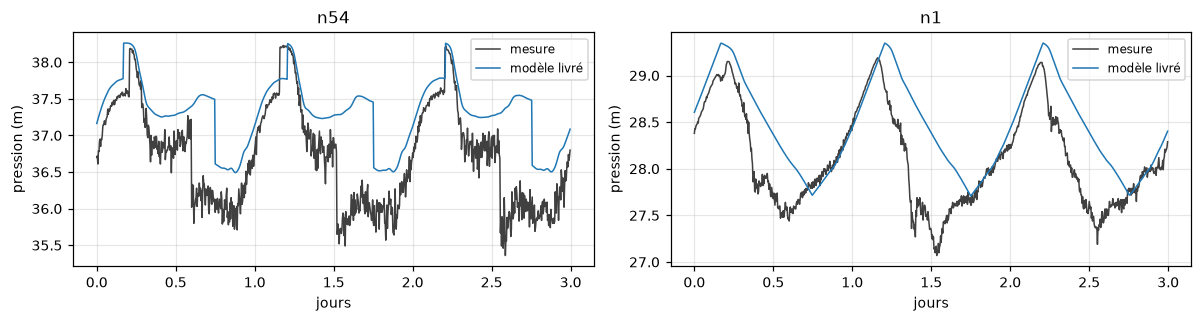

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.0))
G.tracer_capteur(axes[0], S_nominal, mesure, "n54", n_pas=3 * R.PAS_JOUR, etiquette="modèle livré")
G.tracer_capteur(axes[1], S_nominal, mesure, "n1", n_pas=3 * R.PAS_JOUR, etiquette="modèle livré")
fig.tight_layout()


### Pourquoi le modèle livré ne peut pas suivre l'année

Les profils du fichier sont **hebdomadaires** : ils se répètent à l'identique toutes les
semaines, du 1er janvier au 31 décembre. Or la consommation réelle a une saisonnalité annuelle,
et on peut la mesurer directement, sans modèle : la différence entre les débitmètres d'entrée et
celui de la pompe donne, à chaque pas, la consommation de toute la zone A+B.

amplitude annuelle mesurée : 136.8 à 201.1 m³/h (soit ±18% autour de la moyenne)
amplitude annuelle des profils du fichier : 0 % — ils sont strictement hebdomadaires
à noter : le profil industriel du fichier ne contient qu'un point, il est donc constant


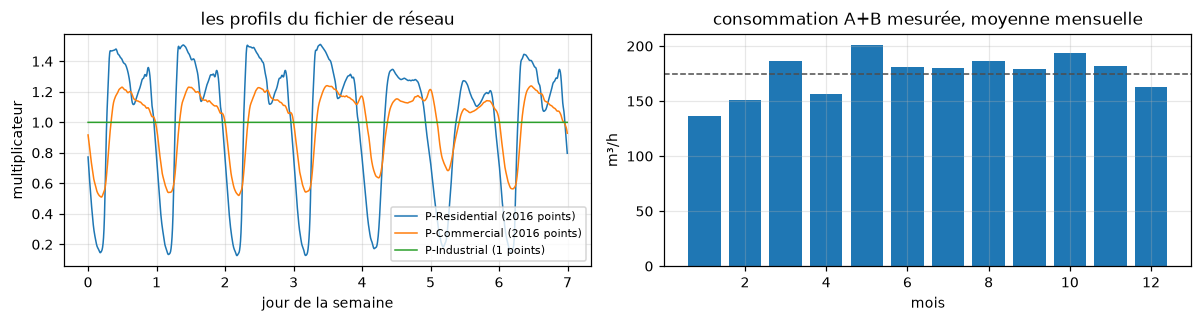

In [6]:
debits = R.charger_debits(ANNEE)
conso_ab = (debits["p227"] + debits["p235"] - debits["PUMP_1"])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.0))
for nom in wn.pattern_name_list:
    m = np.asarray(wn.get_pattern(nom).multipliers)       # P-Industrial ne fait qu'un seul point
    axes[0].plot(np.arange(R.PAS_SEMAINE) / R.PAS_JOUR,
                 m[np.arange(R.PAS_SEMAINE) % len(m)], lw=1, label=f"{nom} ({len(m)} points)")
axes[0].set_xlabel("jour de la semaine"); axes[0].set_ylabel("multiplicateur")
axes[0].set_title("les profils du fichier de réseau"); axes[0].legend(fontsize=7)

mensuel = conso_ab.resample("ME").mean()
axes[1].bar(np.arange(12) + 1, mensuel.to_numpy())
axes[1].axhline(conso_ab.mean(), color="0.3", ls="--", lw=1)
axes[1].set_xlabel("mois"); axes[1].set_ylabel("m³/h")
axes[1].set_title("consommation A+B mesurée, moyenne mensuelle")
fig.tight_layout()

print(f"amplitude annuelle mesurée : {mensuel.min():.1f} à {mensuel.max():.1f} m³/h "
      f"(soit ±{(mensuel.max() - mensuel.min()) / 2 / mensuel.mean():.0%} autour de la moyenne)")
print("amplitude annuelle des profils du fichier : 0 % — ils sont strictement hebdomadaires")
print("à noter : le profil industriel du fichier ne contient qu'un point, il est donc constant")


Le diagnostic est net, et il ne demande aucune modélisation : les profils livrés ignorent une
variation saisonnière de plusieurs dizaines de pour cent. C'est précisément le trou que le modèle
de demande vient combler.

## 3. Équation (1) : décomposer un compteur

$$ d(t) = \bar{d} \cdot T(t) \cdot S(t) \cdot R(t) $$

* $\bar{d}$ : la moyenne annuelle du compteur ;
* $T(t)$ : la **tendance**, moyenne glissante centrée sur une fenêtre d'exactement une semaine.
  Cette largeur annule le cycle hebdomadaire, si bien que ce qui reste est la dérive lente ;
* $S(t)$ : la **saisonnalité hebdomadaire**, obtenue par **moyenne** de créneau sur le signal
  détendancé, renormalisée à une moyenne de 1. Un créneau — « mardi 8 h 05 » — revient 52 fois
  dans l'année, et c'est la moyenne de ces 52 valeurs que la référence retient. `saisonnalite`
  propose aussi la **médiane** en option : plus robuste, puisqu'une poignée de journées atypiques
  suffit à déplacer une moyenne calculée sur 52 points, et que le but de l'étape est justement de
  renvoyer ces journées dans le résidu. Les deux coïncident sur des compteurs propres et divergent
  là où il y a quelque chose à voir ;
* $R(t)$ : le **résidu**, que la méthode jette.

Jeter le résidu est le choix central de la méthode. On ne cherche pas à prédire le bruit de
consommation d'un foyer, on cherche la partie reproductible — celle qui se transportera vers les
nœuds non mesurés.

d̄ = 1.835 m³/h   |   part de variance portée par d̄·T·S : 11.1%


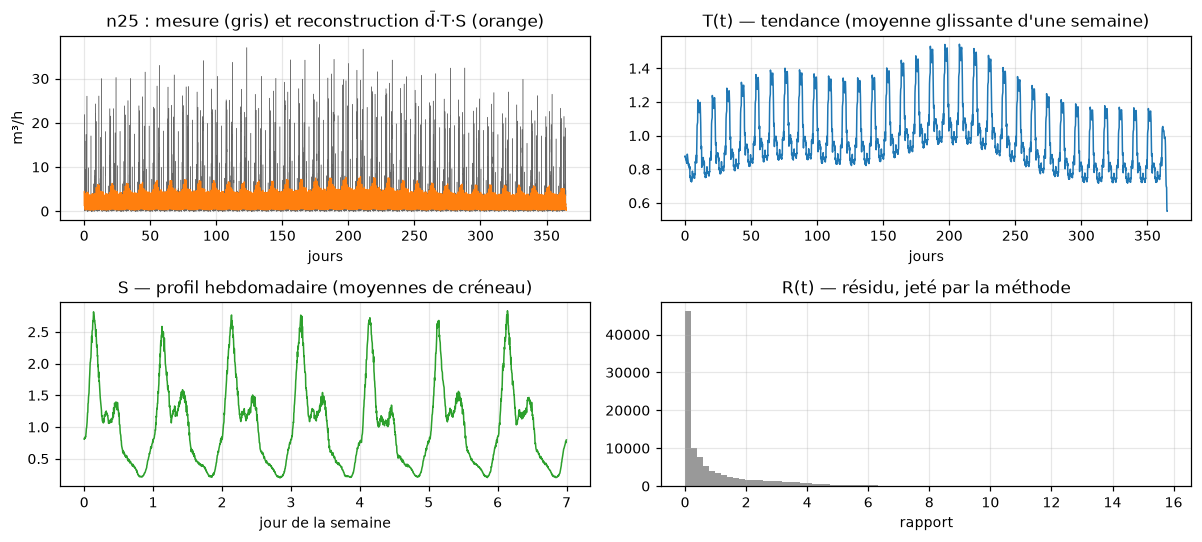

In [7]:
compteur = amr.sum().idxmax()          # le compteur le plus chargé, pour la lisibilité
cr = R.creneau(amr.index)
d = P.decomposer(amr[compteur].to_numpy(), cr)

fig, axes = plt.subplots(2, 2, figsize=(11, 5.0))
j = np.arange(len(amr)) / R.PAS_JOUR

axes[0, 0].plot(j, amr[compteur].to_numpy(), lw=0.3, color="0.4")
axes[0, 0].plot(j, d["lisse"], lw=0.8, color="C1")
axes[0, 0].set_title(f"{compteur} : mesure (gris) et reconstruction d̄·T·S (orange)")
axes[0, 0].set_xlabel("jours"); axes[0, 0].set_ylabel("m³/h")

axes[0, 1].plot(j, d["tendance"], lw=1.0, color="C0")
axes[0, 1].set_title("T(t) — tendance (moyenne glissante d'une semaine)")
axes[0, 1].set_xlabel("jours")

axes[1, 0].plot(np.arange(R.PAS_SEMAINE) / R.PAS_JOUR, d["saison"], lw=1.0, color="C2")
axes[1, 0].set_title("S — profil hebdomadaire (moyennes de créneau)")
axes[1, 0].set_xlabel("jour de la semaine")

axes[1, 1].hist(d["residu"], bins=80, color="0.6")
axes[1, 1].set_title("R(t) — résidu, jeté par la méthode"); axes[1, 1].set_xlabel("rapport")
fig.tight_layout()

var_expliquee = 1 - np.var(amr[compteur].to_numpy() - d["lisse"]) / np.var(amr[compteur].to_numpy())
print(f"d̄ = {d['moyenne']:.3f} m³/h   |   part de variance portée par d̄·T·S : {var_expliquee:.1%}")


À l'échelle d'**un** compteur, le produit $\bar{d}\,T\,S$ n'explique qu'une fraction de la
variance : une consommation individuelle est largement aléatoire. Ce n'est pas un échec de la
méthode, c'est la raison d'être de l'étape suivante. Le résidu d'un foyer est indépendant de
celui du voisin ; en sommant des centaines de nœuds, il s'annule, tandis que la tendance et le
profil hebdomadaire, eux, s'additionnent.

In [8]:
dec = P.decomposer_amr(ANNEE)          # applique l'équation (1) aux 82 compteurs (~15 s)

residu_total = (dec["mesure"].sum(axis=1) - dec["lisse"].sum(axis=1)).to_numpy()
var_tot = 1 - np.var(residu_total) / np.var(dec["mesure"].sum(axis=1).to_numpy())
var_unit = np.mean([1 - np.var(dec["mesure"][c] - dec["lisse"][c]) / np.var(dec["mesure"][c])
                    for c in dec["mesure"].columns])
print(f"variance portée par d̄·T·S, compteur par compteur : {var_unit:.1%}")
print(f"variance portée par d̄·T·S, sur la somme des 82    : {var_tot:.1%}")

variance portée par d̄·T·S, compteur par compteur : 42.1%
variance portée par d̄·T·S, sur la somme des 82    : 71.1%


amplitude restituée sur n25 seul   : 34% de l'écart-type mesuré
amplitude restituée sur la somme des 82 : 85%

n25 : médiane 0.35 m³/h, maximum 37.80, nul 10% du temps — une consommation individuelle est faite de pointes


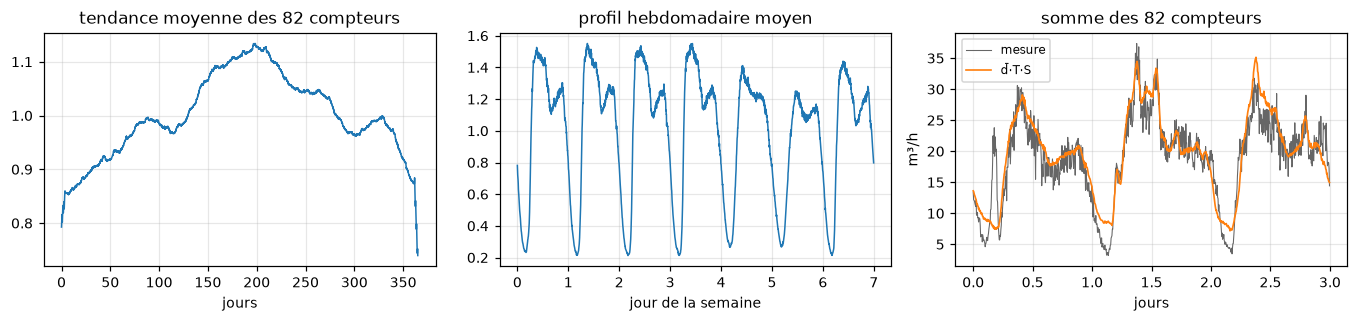

In [9]:
# Un compteur seul contre la somme des 82 : c'est toute la thèse de la section.
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.0))
axes[0].plot(np.arange(len(dec["tendances"])) / R.PAS_JOUR,
             dec["tendances"].mean(axis=1).to_numpy(), lw=1.0)
axes[0].set_title("tendance moyenne des 82 compteurs"); axes[0].set_xlabel("jours")
axes[1].plot(np.arange(R.PAS_SEMAINE) / R.PAS_JOUR, dec["saisons"].mean(axis=1).to_numpy(), lw=1.0)
axes[1].set_title("profil hebdomadaire moyen"); axes[1].set_xlabel("jour de la semaine")

jours = slice(DEBUT, DEBUT + 3 * R.PAS_JOUR)
t3 = np.arange(3 * R.PAS_JOUR) / R.PAS_JOUR
axes[2].plot(t3, dec["mesure"].sum(axis=1).to_numpy()[jours], lw=0.7, color="0.4", label="mesure")
axes[2].plot(t3, dec["lisse"].sum(axis=1).to_numpy()[jours], lw=1.1, color="C1", label="d̄·T·S")
axes[2].set_title("somme des 82 compteurs"); axes[2].set_xlabel("jours")
axes[2].set_ylabel("m³/h"); axes[2].legend(fontsize=8)
fig.tight_layout()

un = dec["mesure"][compteur].to_numpy()
somme = dec["mesure"].sum(axis=1).to_numpy()
print(f"amplitude restituée sur {compteur} seul   : "
      f"{dec['lisse'][compteur].std() / un.std():.0%} de l'écart-type mesuré")
print(f"amplitude restituée sur la somme des 82 : "
      f"{dec['lisse'].sum(axis=1).std() / somme.std():.0%}")
print(f"\n{compteur} : médiane {np.median(un):.2f} m³/h, maximum {un.max():.2f}, "
      f"nul {np.mean(un == 0):.0%} du temps — une consommation individuelle est faite de pointes")


## 4. Équation (2) : des compteurs vers les nœuds sans mesure

$$ \hat{d}_i(t) = \sum_j \bar{d}_{ij} \cdot T_j(t) \cdot S_j(t) $$

Attention à la lecture : cette équation est un **mélange**, une somme sur les types de
consommateurs $j$, et non un produit. Le produit de l'équation (1) porte sur les effets temporels
d'un même compteur ; la somme ici répartit un nœud entre plusieurs types.

Les poids $\bar{d}_{ij}$ sont donnés : le fichier de réseau attribue à chaque jonction trois
demandes de base, une par type. Ce sont les formes $T_j\!\cdot\!S_j$ qu'il faut estimer — et on
les obtient en résolvant cette même équation **à l'envers** là où la mesure existe. Avec $W$ la
matrice 82 × 3 des demandes nominales des nœuds équipés et $A$ les séries lissées par l'équation
(1), on résout $W\,m(t) = A(t)$ aux moindres carrés, à chaque pas.

In [10]:
# Comment le fichier répartit la demande entre les trois types de consommateurs.
bases = R.bases_nominales(wn)
zone = pd.Series(R.zones(wn))
n_types = (bases > 0).sum(axis=1)

print("nombre de types de consommateurs par jonction :")
print(pd.crosstab(zone, n_types, rownames=["zone"], colnames=["types portés"]).to_string())
print("\ndemande nominale par zone et par type (m³/h) :")
print(bases.groupby(zone).sum().round(2).to_string())
print(f"\nnœuds portant de l'industriel : {list(bases[bases.Industrial > 0].index)}")
print(f"  tous en zone C et tous équipés d'un compteur : "
      f"{all(zone[n] == 'C' and n in amr.columns for n in bases[bases.Industrial > 0].index)}")

nombre de types de consommateurs par jonction :
types portés   0    1    2
zone                      
AB            35  102  553
C              0   84    8

demande nominale par zone et par type (m³/h) :
    Residential  Commercial  Industrial
AB        92.23       64.76        0.00
C         13.85        1.79        3.94

nœuds portant de l'industriel : ['n1', 'n4', 'n25', 'n347']
  tous en zone C et tous équipés d'un compteur : True


Trois choses à retenir de ce tableau, et elles changent la lecture de l'équation (2).

**Aucune jonction ne porte les trois types.** 186 n'en portent qu'un, 561 en portent exactement
deux — toujours résidentiel + commercial — et 35 n'ont aucune demande. La somme de l'équation (2)
n'a donc jamais plus de deux termes.

**La demande industrielle vaut exactement zéro dans la zone A+B.** Elle n'existe que sur quatre
nœuds, tous en zone C, et tous équipés d'un compteur.

**Donc la forme industrielle n'est jamais extrapolée.** C'est la plus bruitée des trois — on la
verra plus bas, estimée sur quatre compteurs — mais elle ne sert qu'à des nœuds dont on mesure
déjà la consommation. Le risque se limite à ce qu'elle absorbe du bruit au détriment des deux
autres lors de l'inversion, ce que le conditionnement de $W$ permet de contrôler.

Residential    1.30
Commercial     1.32
Industrial     1.36


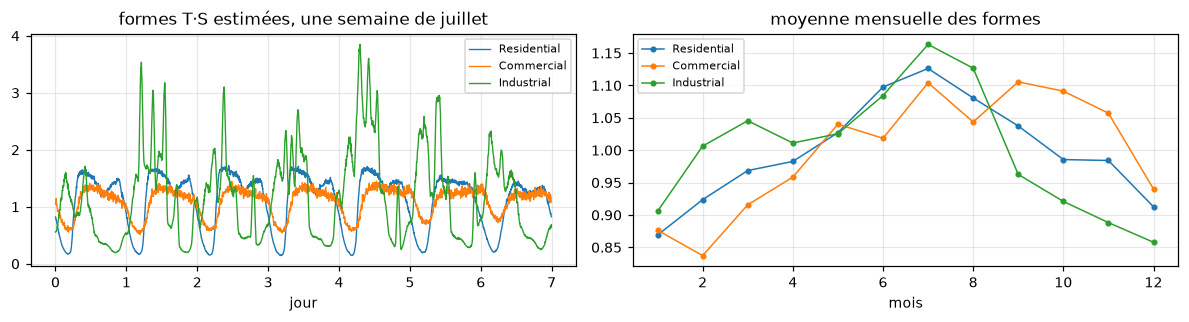

In [11]:
formes = P.formes_par_categorie(wn, ANNEE, dec)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.0))
sem = slice(DEBUT, DEBUT + R.PAS_SEMAINE)
for c in formes.columns:
    axes[0].plot(np.arange(R.PAS_SEMAINE) / R.PAS_JOUR, formes[c].to_numpy()[sem], lw=0.9, label=c)
axes[0].set_title("formes T·S estimées, une semaine de juillet")
axes[0].set_xlabel("jour"); axes[0].legend(fontsize=7)

mens = formes.resample("ME").mean()
for c in formes.columns:
    axes[1].plot(np.arange(12) + 1, mens[c].to_numpy(), marker="o", ms=3, lw=1, label=c)
axes[1].set_title("moyenne mensuelle des formes"); axes[1].set_xlabel("mois")
axes[1].legend(fontsize=7)
fig.tight_layout()

print((mens.max() / mens.min()).round(2).to_string())

**Première réserve : le profil industriel n'est pas un résultat.**

Il est estimé sur **4 nœuds équipés** seulement — contre 75 pour le résidentiel et 10 pour le
commercial — et c'est pourtant la forme la plus agitée des trois. Ce n'est pas un signal
industriel, c'est le bruit de quatre compteurs.

Ce qui limite les dégâts est plus fort qu'une question de poids : ces quatre nœuds sont **les
seuls** du réseau à porter de l'industriel, ils sont tous en zone C, et ils sont tous équipés. La
forme industrielle n'est donc jamais transportée vers un nœud non mesuré.

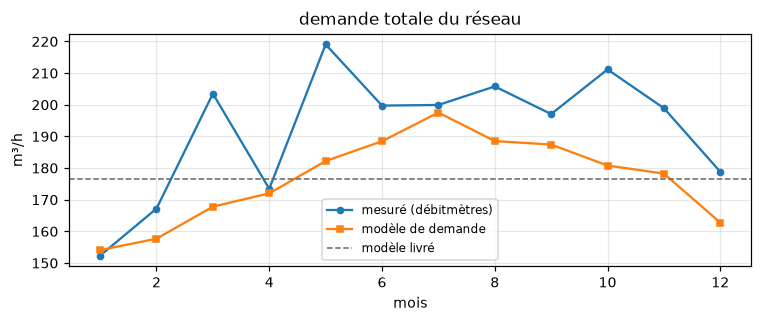

In [12]:
D_calibre, noeuds_c = P.demandes_calibrees(wn, ANNEE, formes)
assert noeuds_c == noeuds

# Contrôle indépendant : la demande totale du modèle contre le bilan de masse des débitmètres
total_modele = pd.Series(D_calibre.sum(axis=1), index=horo).resample("ME").mean()
total_nominal = P.demandes_nominales(wn, horo[:R.PAS_SEMAINE])[0].sum(axis=1).mean()
total_mesure = (conso_ab + R.charger_amr(ANNEE).sum(axis=1)).resample("ME").mean()

fig, ax = plt.subplots(figsize=(7, 3.0))
ax.plot(np.arange(12) + 1, total_mesure.to_numpy(), marker="o", ms=4, label="mesuré (débitmètres)")
ax.plot(np.arange(12) + 1, total_modele.to_numpy(), marker="s", ms=4, label="modèle de demande")
ax.axhline(total_nominal, color="0.4", ls="--", lw=1, label="modèle livré")
ax.set_xlabel("mois"); ax.set_ylabel("m³/h"); ax.set_title("demande totale du réseau")
ax.legend(fontsize=8)
fig.tight_layout()

La forme saisonnière est retrouvée, et il reste un **écart de niveau** : le modèle de demande est
systématiquement en dessous de ce que les débitmètres mesurent.

Cet écart n'est pas un défaut du modèle. Le bilan de masse `p227 + p235 − PUMP_1` mesure tout ce
qui **sort** vers la zone A+B, ce qui inclut ce qui y fuit ; le modèle de demande, lui, ne
reconstruit que ce qui est **consommé**. Le carnet 4 fait la soustraction avec les fuites publiées
par le jeu de données : le modèle tombe alors à **+0,2 %** de la consommation réelle de A+B sur
l'année, et l'intégralité de l'écart au bilan brut est de la fuite.

C'est à retenir pour le second carnet, qui recale la demande sur ce bilan **brut** : le recalage
améliore les pressions parce que cette eau circule réellement, mais il inscrit la fuite dans la
demande.

## 5. Ce que le modèle de demande change sur les pressions

In [13]:
S_demande = R.pressions_simulees(D_calibre[DEBUT:DEBUT + N_PAS + 1], noeuds, N_PAS,
                                 tranche_jours=7, niveau0=float(niveau[DEBUT]), verbeux=False)

variantes = {"modèle livré": S_nominal, "modèle de demande": S_demande}
print(G.tableau(variantes, mesure).round(4).to_string())

                   biais_m  dispersion_m  rmse_m   max_m   n_pas  gain_dispersion  gain_rmse
modèle livré        0.3412        0.3290  0.4740  2.2851  2016.0           0.0000     0.0000
modèle de demande   0.2022        0.2526  0.3235  1.7974  2016.0          -0.2324    -0.3174


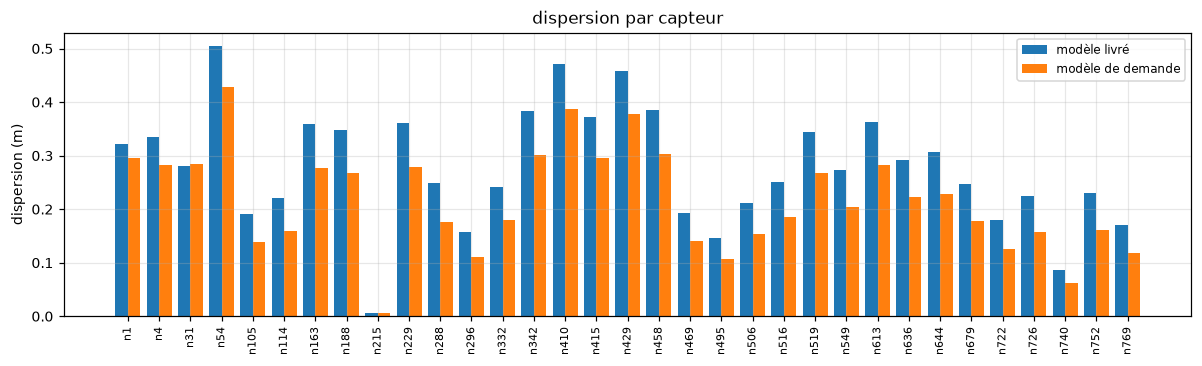

In [14]:
fig, ax = plt.subplots(figsize=(11, 3.4))
G.tracer_par_capteur(ax, {k: G.par_capteur(v, mesure) for k, v in variantes.items()},
                     "dispersion_m")
ax.set_title("dispersion par capteur")
fig.tight_layout()


## 6. Les rugosités : six groupes et moindres carrés sous contraintes

Il reste le second volet de la méthode. Les 905 conduites n'entrent dans les équations que par
leur résistance

$$ R = \frac{10{,}674\,L}{C^{1,852} D^{4,871}} $$

et l'on ne dispose que de 33 capteurs de pression. Les calibrer une par une n'aurait aucun sens :
la méthode les **regroupe** — conduites de même matériau, âge, diamètre et conditions
hydrauliques — et n'ajuste qu'un coefficient par groupe. Six groupes, formés ici par classe de
diamètre.

Le critère minimisé n'est pas une simple somme de carrés. C'est un moindres carrés pondéré
**sous contraintes de boîte**, avec perte de **Huber** contre les pas de temps aberrants et
**régularisation de Tikhonov** vers la valeur du fichier de réseau :

$$ \min_{x_L \le x \le x_U} \ \tfrac12 \sum_j \sum_i H_\kappa\!\left(\frac{[S\,y(t_j,x)]_i - z^j_i}{\sigma_{ij}}\right) + \alpha \lVert x - x_0 \rVert^2 $$

`rugosite.ajuster` implémente les trois, mais **deux seulement sont actifs ici** : les bornes
(60 à 160, l'encadrement de la référence) et la perte de Huber. Le coefficient de régularisation
vaut zéro par défaut, et ce carnet ne le modifie pas — il reproduit la référence à ce détail
près. Le second carnet mesure ce que valent ces garde-fous, ce qui se passe quand on les enlève,
et ce que donne un encadrement construit sur le fichier plutôt que sur la publication.

Le solveur n'est pas Levenberg-Marquardt au sens strict mais une région de confiance
réfléchissante : LM n'accepte pas de bornes, or le critère ci-dessus en pose.

**Sur quelle fenêtre ajuster ?** La référence règle sur la première semaine de l'année, et ce
carnet fait de même (`DEBUT_ENTR = 0`) — alors qu'il *évalue* en juillet. Ce n'est pas un détail
de mise en œuvre : c'est la seule semaine de l'année qui ne porte aucune fuite. Une fuite fait
baisser la pression en aval, un excès de friction aussi, et un optimiseur qui n'a que la rugosité
sous la main ne peut pas les distinguer — il paie la fuite avec de la rugosité. Le second carnet
mesure ce que ça coûte quand on s'y prend mal.

In [15]:
groupes = R.groupes_de_rugosite(wn, n_groupes=6)
noms_groupes = sorted(set(groupes.values()))
depart = U.coefficients_initiaux(wn, groupes)
print(pd.Series(groupes).value_counts().to_string())

D100     705
D150     103
D200      64
D160      16
D225      12
D<=75      5


In [16]:
mesure_entr = R.charger_pressions(ANNEE).to_numpy()[DEBUT_ENTR:DEBUT_ENTR + N_ENTR]

def simulateur(coefficients):
    # une évaluation = une simulation complète de la fenêtre d'ajustement
    return R.pressions_simulees(D_calibre[DEBUT_ENTR:DEBUT_ENTR + N_ENTR + 1], noeuds, N_ENTR,
                                tranche_jours=7, niveau0=float(niveau[DEBUT_ENTR]), verbeux=False,
                                coefficients=U.coefficients_par_conduite(groupes, coefficients))

# attention au coût : chaque colonne du jacobien demande une simulation de plus, si bien que le
# nombre de simulations réellement lancées dépasse largement `max_nfev`
ajustement = U.ajuster(simulateur, mesure_entr, depart, max_nfev=12, verbeux=False)
print(f"{ajustement['n_evaluations']} simulations en {ajustement['secondes']:.0f} s")
print(f"RMSE sur la fenêtre d'ajustement : {ajustement['rmse_depart']:.4f} → {ajustement['rmse']:.4f} m")
print("\ncoefficients de Hazen-Williams retenus :")
print(pd.Series(ajustement["coefficients"]).round(1).to_string())
print(f"\ndépart : {pd.Series(ajustement['depart']).round(1).to_dict()}")
print(f"groupes arrêtés sur une borne : {ajustement['aux_bornes'] or 'aucun'}")

55 simulations en 54 s
RMSE sur la fenêtre d'ajustement : 0.2455 → 0.2099 m

coefficients de Hazen-Williams retenus :
D100     112.1
D150     137.1
D160     158.3
D200     124.8
D225      70.0
D<=75    157.6

départ : {'D100': 137.1, 'D150': 137.7, 'D160': 140.0, 'D200': 140.0, 'D225': 140.0, 'D<=75': 135.3}
groupes arrêtés sur une borne : aucun


In [17]:
S_rugosite = R.pressions_simulees(
    D_calibre[DEBUT:DEBUT + N_PAS + 1], noeuds, N_PAS, tranche_jours=7,
    niveau0=float(niveau[DEBUT]), verbeux=False,
    coefficients=U.coefficients_par_conduite(groupes, ajustement["coefficients"]))

variantes["+ rugosités ajustées"] = S_rugosite
print(G.tableau(variantes, mesure).round(4).to_string())

                      biais_m  dispersion_m  rmse_m   max_m   n_pas  gain_dispersion  gain_rmse
modèle livré           0.3412        0.3290  0.4740  2.2851  2016.0           0.0000     0.0000
modèle de demande      0.2022        0.2526  0.3235  1.7974  2016.0          -0.2324    -0.3174
+ rugosités ajustées   0.0195        0.2584  0.2591  1.6679  2016.0          -0.2146    -0.4532



## 7. Bilan

Reprenons les trois variantes sur deux saisons, pour ne pas conclure sur une semaine
particulière.

In [18]:
def evaluer(debut, n=3 * R.PAS_JOUR):
    mes = R.charger_pressions(ANNEE).to_numpy()[debut:debut + n]
    Dn, _ = P.demandes_nominales(wn, horo[debut:debut + n + 1])
    faire = lambda D, **kw: R.pressions_simulees(D, noeuds, n, tranche_jours=7,
                                                 niveau0=float(niveau[debut]), verbeux=False, **kw)
    v = {"modèle livré": faire(Dn),
         "modèle de demande": faire(D_calibre[debut:debut + n + 1]),
         "+ rugosités ajustées": faire(
             D_calibre[debut:debut + n + 1],
             coefficients=U.coefficients_par_conduite(groupes, ajustement["coefficients"]))}
    return G.tableau(v, mes)

bilan = pd.concat({"janvier": evaluer(3 * R.PAS_JOUR), "juillet": evaluer(DEBUT)})
print(bilan[["biais_m", "dispersion_m", "rmse_m", "gain_dispersion"]].round(4).to_string())

                              biais_m  dispersion_m  rmse_m  gain_dispersion
janvier modèle livré          -0.1428        0.2162  0.2591           0.0000
        modèle de demande      0.0536        0.1229  0.1341          -0.4318
        + rugosités ajustées  -0.0541        0.1144  0.1265          -0.4709
juillet modèle livré           0.3320        0.3090  0.4535           0.0000
        modèle de demande      0.2050        0.2289  0.3072          -0.2594
        + rugosités ajustées   0.0196        0.2140  0.2149          -0.3075



### Lecture

Trois constats, qu'il vaut mieux énoncer tels quels que raboter :

1. **Le modèle de demande apporte la saisonnalité annuelle**, qui manquait complètement. Le gain
   sur la dispersion est net dans les deux saisons, et il est plus fort en hiver qu'en été.
2. **Il reste un biais important en été.** La reconstruction extrapolée d'une zone à l'autre
   retrouve la *forme* de la demande mieux que son *niveau* — et le niveau, lui, se mesure
   directement aux débitmètres. Le second carnet s'en sert.
3. **L'ajustement des rugosités agit sur le biais, pas sur la dynamique.** Il ramène le décalage
   de +0,20 m à +0,02 m, tandis que la dispersion ne bouge quasiment pas — elle se dégrade même
   un peu ici, et s'améliore un peu en janvier. La RMSE s'améliore donc beaucoup, et le modèle
   guère. À noter que cette fois **aucun groupe ne s'arrête sur une borne** : réglés sur une
   semaine sans fuite, les coefficients restent dans une plage plausible. Le second carnet reprend ce point : une mesure directe sur le
   réseau explique pourquoi la friction ne donne presque aucune prise ici, et une fenêtre de
   transfert montre ce que ces six paramètres ont réellement appris.

Et un constat de méthode, qui commande la suite : une part importante de l'erreur restante est un
**biais**, et le biais ne dit rien de la dynamique. Le second carnet s'attaque à ce qui reste —
en regardant, non pas ce que le modèle de demande pourrait faire de mieux, mais ce que les
capteurs disent déjà et que le modèle n'écoute pas.